In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [13]:
import matplotlib.font_manager as fm

# 设置字体为 SimHei (黑体)
plt.rcParams['font.sans-serif'] = ['SimHei']

# 设置负号的正常显示
plt.rcParams['axes.unicode_minus'] = False

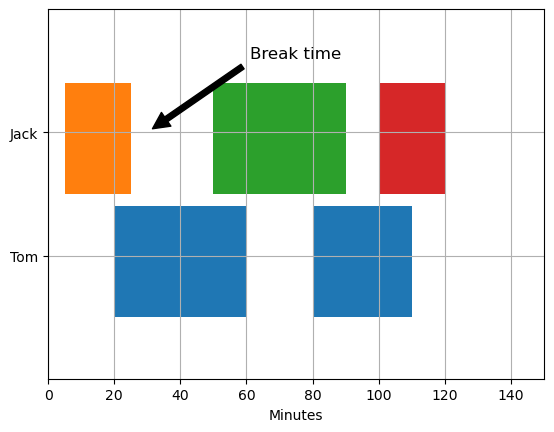

In [3]:
# 水平条形图显示任务进度
fig, ax = plt.subplots()

# 工人Tom和Jack完成的任务及时间间隔
ax.broken_barh([(20, 40), (80, 30)], (10, 9), facecolors='tab:blue')  # Tom的任务时间段
ax.broken_barh([(5, 20), (50, 40), (100, 20)], (20, 9),               # Jack的任务时间段
               facecolors=('tab:orange', 'tab:green', 'tab:red'))

# 设置坐标轴限制和标签
ax.set_ylim(5, 35)
ax.set_xlim(0, 150)
ax.set_xlabel('Minutes')
ax.set_yticks([15, 25], labels=['Tom', 'Jack'])  # 修改y轴标签，显示工人名称
ax.grid(True)  # 显示网格线

# 添加注释，指出某个重要事件
ax.annotate('Break time', (30, 25),
            xytext=(0.5, 0.9), textcoords='axes fraction',
            arrowprops=dict(facecolor='black', shrink=0.05),
            fontsize=12,
            horizontalalignment='center', verticalalignment='top')

plt.show()


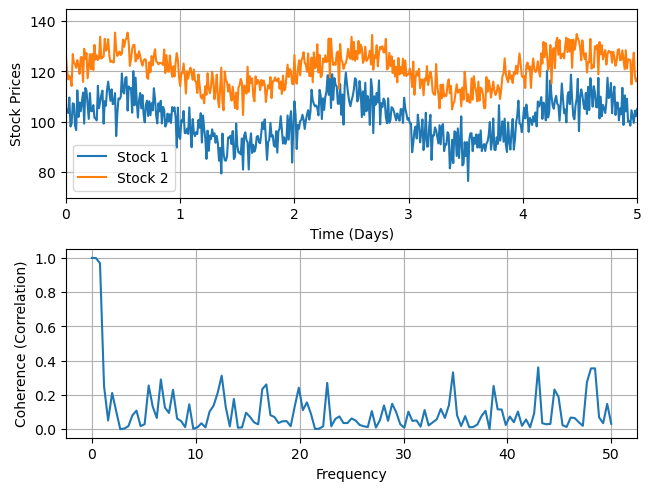

In [5]:
# 随机数生成器用于可重复性
np.random.seed(19680801)

dt = 0.01
t = np.arange(0, 30, dt)

# 两个股票的随机价格波动
stock1_noise = np.random.randn(len(t)) * 5  # 噪音波动
stock2_noise = np.random.randn(len(t)) * 4

# 两个股票的价格趋势，叠加噪音部分
stock1 = 100 + np.sin(2 * np.pi * 0.5 * t) * 10 + stock1_noise  # 股票1价格
stock2 = 120 + np.sin(2 * np.pi * 0.5 * t) * 8 + stock2_noise   # 股票2价格

fig, axs = plt.subplots(2, 1, layout='constrained')

# 绘制两个股票的价格趋势
axs[0].plot(t, stock1, label="Stock 1")
axs[0].plot(t, stock2, label="Stock 2")
axs[0].set_xlim(0, 5)
axs[0].set_xlabel('Time (Days)')
axs[0].set_ylabel('Stock Prices')
axs[0].grid(True)
axs[0].legend()

# 计算并绘制两个股票的相关性
cxy, f = axs[1].cohere(stock1, stock2, 256, 1. / dt)
axs[1].set_ylabel('Coherence (Correlation)')

plt.show()


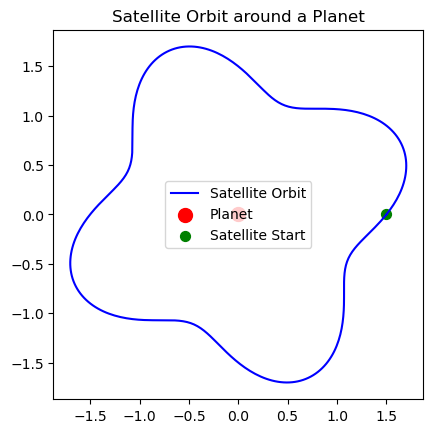

In [7]:
N = 400
t = np.linspace(0, 2 * np.pi, N)

# 卫星轨道半径和轨迹（加入更多的不规则波动）
r = 1.5 + 0.3 * np.sin(4 * t)  # 半径随角度变化
x, y = r * np.cos(t), r * np.sin(t)

# 绘制卫星的轨迹
fig, ax = plt.subplots()
ax.plot(x, y, "b", label="Satellite Orbit")  # 绘制轨迹线
ax.scatter(0, 0, color='red', s=100, label="Planet")  # 中心的行星
ax.scatter(x[0], y[0], color='green', s=50, label="Satellite Start")  # 起始位置

# 设置坐标轴样式
ax.set(aspect=1)
ax.set_title("Satellite Orbit around a Planet")
ax.legend()

plt.show()


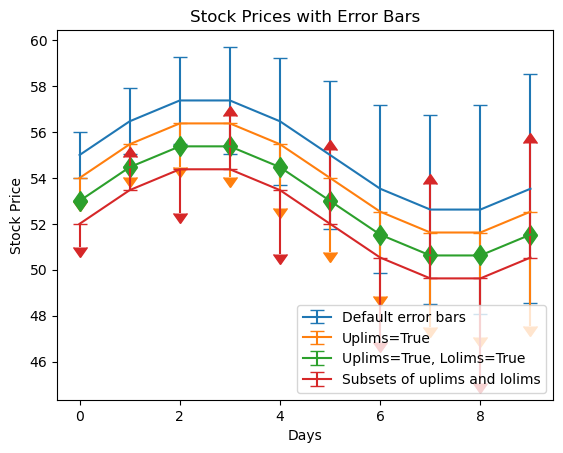

In [9]:
# Data
fig = plt.figure()
days = np.arange(10)
prices = 50 + 2.5 * np.sin(days / 5 * np.pi)  # Simulated stock prices
price_errors = np.linspace(1, 5, 10)  # Error bars representing uncertainty in stock prices

# Plot with different error bar styles
plt.errorbar(days, prices + 5, yerr=price_errors, label='Default error bars', capsize=5)

plt.errorbar(days, prices + 4, yerr=price_errors, uplims=True, label='Uplims=True', capsize=5)

plt.errorbar(days, prices + 3, yerr=price_errors, uplims=True, lolims=True,
             label='Uplims=True, Lolims=True', capsize=5)

# Upper and lower limits
upperlimits = [True, False] * 5
lowerlimits = [False, True] * 5
plt.errorbar(days, prices + 2, yerr=price_errors, uplims=upperlimits, lolims=lowerlimits,
             label='Subsets of uplims and lolims', capsize=5)

# Adding titles and labels
plt.xlabel('Days')
plt.ylabel('Stock Price')
plt.title('Stock Prices with Error Bars')
plt.legend(loc='lower right')

plt.show()

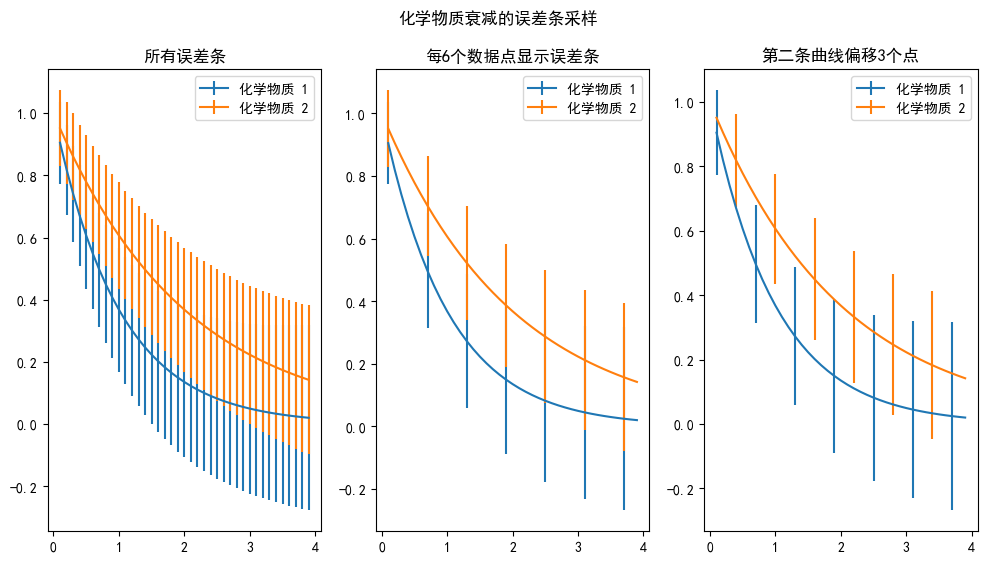

In [15]:
# 时间数据
time = np.arange(0.1, 4, 0.1)

# 两种化学物质的衰减速率
decay_chem1 = np.exp(-1.0 * time)  # 快速衰减
decay_chem2 = np.exp(-0.5 * time)  # 缓慢衰减

# 示例误差条数据
decay_chem1_err = 0.1 + 0.1 * np.sqrt(time)
decay_chem2_err = 0.1 + 0.1 * np.sqrt(time / 2)

# 创建多个子图
fig, (ax0, ax1, ax2) = plt.subplots(nrows=1, ncols=3, sharex=True,
                                    figsize=(12, 6))

# 第一个子图：所有误差条
ax0.set_title('所有误差条')
ax0.errorbar(time, decay_chem1, yerr=decay_chem1_err, label='化学物质 1')
ax0.errorbar(time, decay_chem2, yerr=decay_chem2_err, label='化学物质 2')
ax0.legend()

# 第二个子图：每6个数据点显示误差条
ax1.set_title('每6个数据点显示误差条')
ax1.errorbar(time, decay_chem1, yerr=decay_chem1_err, errorevery=6, label='化学物质 1')
ax1.errorbar(time, decay_chem2, yerr=decay_chem2_err, errorevery=6, label='化学物质 2')
ax1.legend()

# 第三个子图：第二条曲线偏移3个点
ax2.set_title('第二条曲线偏移3个点')
ax2.errorbar(time, decay_chem1, yerr=decay_chem1_err, errorevery=(0, 6), label='化学物质 1')
ax2.errorbar(time, decay_chem2, yerr=decay_chem2_err, errorevery=(3, 6), label='化学物质 2')
ax2.legend()

# 设置图表标题
fig.suptitle('化学物质衰减的误差条采样')
plt.show()


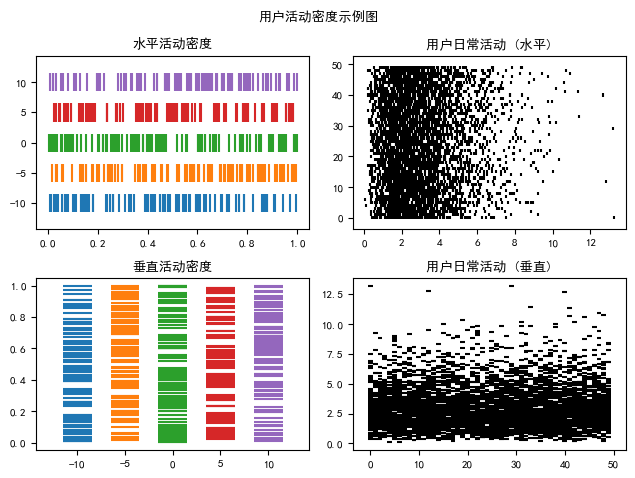

In [17]:
import matplotlib

# 设置字体大小
matplotlib.rcParams['font.size'] = 8.0

# 固定随机数种子以便重现
np.random.seed(20230901)

# 模拟不同年龄段用户的活动密度数据
data_age_groups = np.random.random([5, 100])

# 设置每个年龄段的不同颜色
colors_age = ['C0', 'C1', 'C2', 'C3', 'C4']

# 设置每个年龄段的线条偏移量和线条长度
lineoffsets_age = [-10, -5, 0, 5, 10]
linelengths_age = [3, 3, 3, 3, 3]

# 创建子图
fig, axs = plt.subplots(2, 2)

# 第一个图：水平显示不同年龄段的活动密度
axs[0, 0].eventplot(data_age_groups, colors=colors_age, lineoffsets=lineoffsets_age,
                    linelengths=linelengths_age)
axs[0, 0].set_title('水平活动密度')

# 第二个图：垂直显示不同年龄段的活动密度
axs[1, 0].eventplot(data_age_groups, colors=colors_age, lineoffsets=lineoffsets_age,
                    linelengths=linelengths_age, orientation='vertical')
axs[1, 0].set_title('垂直活动密度')

# 生成另一组模拟数据表示用户每天的活动
data_daily_activity = np.random.gamma(3, size=[50, 100])

# 第三个图：使用固定的黑色线条和偏移量显示用户日常活动密度
axs[0, 1].eventplot(data_daily_activity, colors='black', lineoffsets=1, linelengths=1)
axs[0, 1].set_title('用户日常活动 (水平)')

# 第四个图：垂直显示用户日常活动密度
axs[1, 1].eventplot(data_daily_activity, colors='black', lineoffsets=1, linelengths=1, orientation='vertical')
axs[1, 1].set_title('用户日常活动 (垂直)')

# 显示图形
plt.suptitle('用户活动密度示例图')
plt.tight_layout()
plt.show()


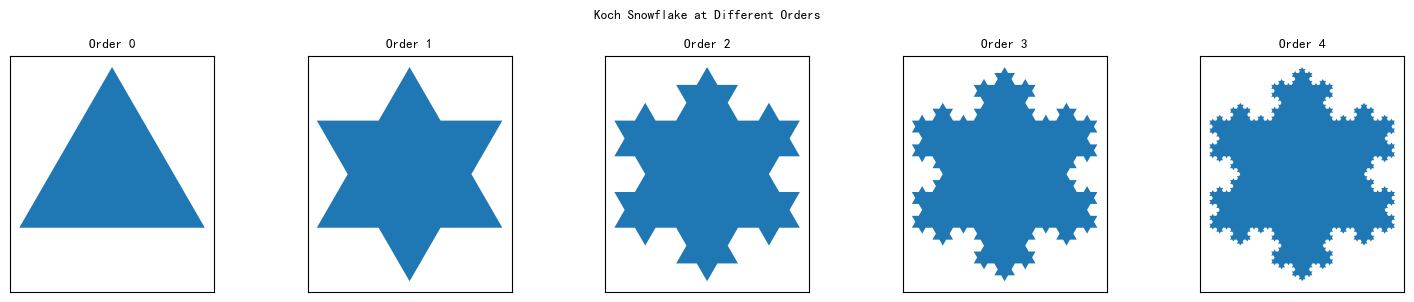

In [19]:
# 定义函数生成科赫雪花
def koch_snowflake(order, scale=10):
    """
    返回科赫雪花的x, y坐标。

    参数
    ----------
    order : int
        递归深度。
    scale : float
        雪花的尺寸（初始三角形边长）。
    """
    def _koch_snowflake_complex(order):
        if order == 0:
            # 初始三角形
            angles = np.array([0, 120, 240]) + 90
            return scale / np.sqrt(3) * np.exp(np.deg2rad(angles) * 1j)
        else:
            ZR = 0.5 - 0.5j * np.sqrt(3) / 3

            p1 = _koch_snowflake_complex(order - 1)  # 起点
            p2 = np.roll(p1, shift=-1)  # 终点
            dp = p2 - p1  # 连接向量

            new_points = np.empty(len(p1) * 4, dtype=np.complex128)
            new_points[::4] = p1
            new_points[1::4] = p1 + dp / 3
            new_points[2::4] = p1 + dp * ZR
            new_points[3::4] = p1 + dp / 3 * 2
            return new_points

    points = _koch_snowflake_complex(order)
    x, y = points.real, points.imag
    return x, y

# 使用不同的递归深度生成图像
orders = [0, 1, 2, 3, 4]

fig, axs = plt.subplots(1, len(orders), figsize=(15, 3), sharey=True)

for ax, order in zip(axs, orders):
    x, y = koch_snowflake(order)
    ax.fill(x, y)
    ax.set_title(f"Order {order}")
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Koch Snowflake at Different Orders")
plt.tight_layout()
plt.show()
